# Visualizador & Dashboard
**Proyecto:** Optimización Logística E-Commerce México

**Responsable:** Persona 4 Data Analyst (Analista de Datos)

## Objetivo del Análisis
Convertir los datos y análisis en visualizaciones claras, atractivas e interactivas que permitan entender rápidamente los hallazgos y apoyar la toma de decisiones, tanto para usuarios técnicos como no técnicos.

Revisaremos por medio de graficas la forma en como se comportan los datos y nos brindan informacion para tomar decision



### 1. Histograma del tiempo de entrega

Este gráfico muestra cómo se distribuyen los tiempos de entrega de los pedidos. Podemos ver en qué rango de días se concentra la mayoría de las entregas.

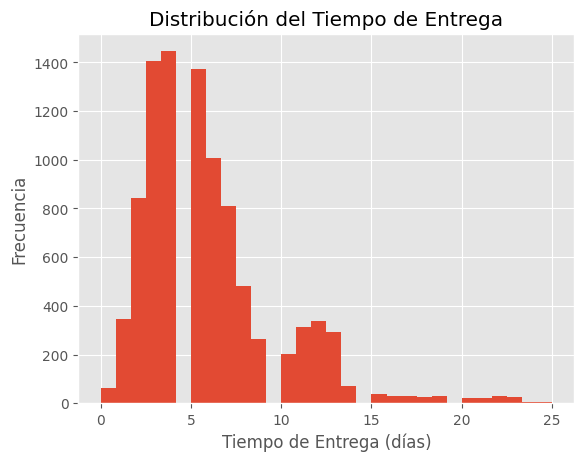

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

df = pd.read_csv("dataset_clean.csv")

# 1️⃣ Histograma del tiempo de entrega
plt.figure()
plt.hist(df["delivery_days"], bins=30)
plt.title("Distribución del Tiempo de Entrega")
plt.xlabel("Tiempo de Entrega (días)")
plt.ylabel("Frecuencia")
plt.show()

### 2. Boxplot por tipo de envío
Aquí comparamos los tiempos de entrega según el tipo de envío. Las cajas nos muestran la mediana, el rango y los valores atípicos, para identificar qué tipo de envío es más rápido o más variable.

<Figure size 640x480 with 0 Axes>

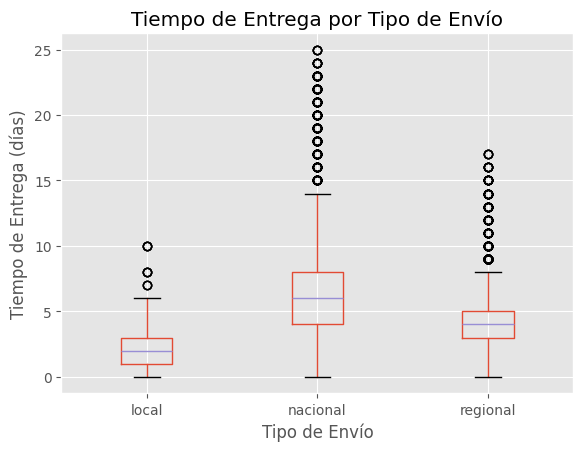

In [2]:
plt.figure()
df.boxplot(column="delivery_days", by="shipping_type")
plt.title("Tiempo de Entrega por Tipo de Envío")
plt.suptitle("")
plt.xlabel("Tipo de Envío")
plt.ylabel("Tiempo de Entrega (días)")
plt.show()

### 3. Scatter distancia vs tiempo
Este diagrama de dispersión nos permite ver la relación entre la distancia del envío y el tiempo de entrega. Si los puntos suben a medida que aumenta la distancia, significa que los envíos largos tardan más.

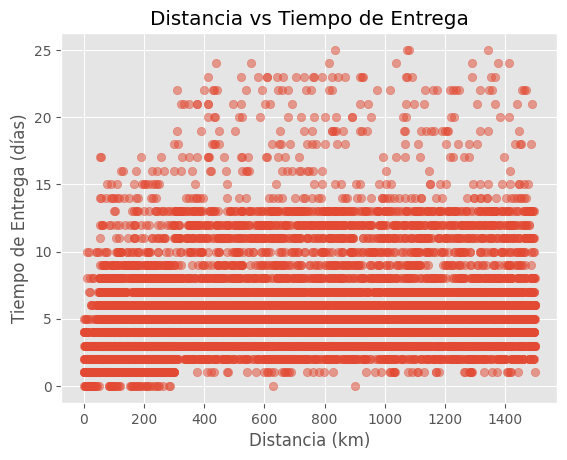

In [3]:
# 3️⃣ Scatter distancia vs tiempo
plt.figure()
plt.scatter(df["distance_km"], df["delivery_days"], alpha=0.5)
plt.title("Distancia vs Tiempo de Entrega")
plt.xlabel("Distancia (km)")
plt.ylabel("Tiempo de Entrega (días)")
plt.show()

### 4. Promedio por paquetería
"Este gráfico de barras muestra el tiempo promedio de entrega por cada paquetería. Nos ayuda a comparar la eficiencia de las distintas empresas de envío."

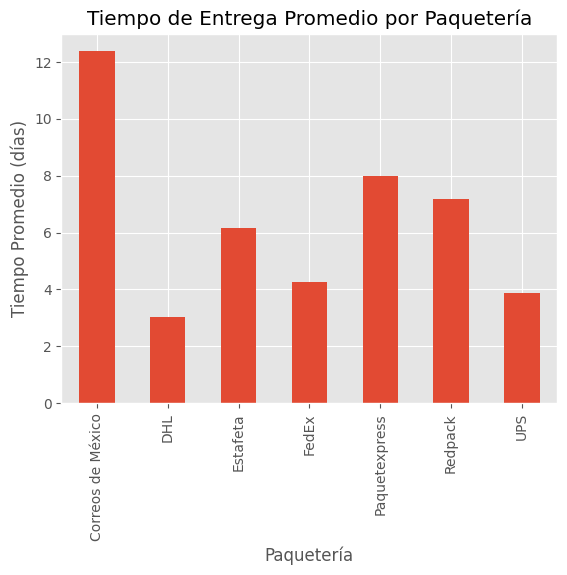

In [4]:

# 4️⃣ Promedio por paquetería
promedio_paq = df.groupby("shipping_carrier")["delivery_days"].mean()

plt.figure()
promedio_paq.plot(kind="bar")
plt.title("Tiempo de Entrega Promedio por Paquetería")
plt.xlabel("Paquetería")
plt.ylabel("Tiempo Promedio (días)")
plt.show()

### 5. Heatmap de correlación
Aquí vemos un mapa de colores que indica cómo se relacionan algunas variables, como días de entrega, distancia o cantidad de productos. Los colores muestran qué variables tienden a subir o bajar juntas.

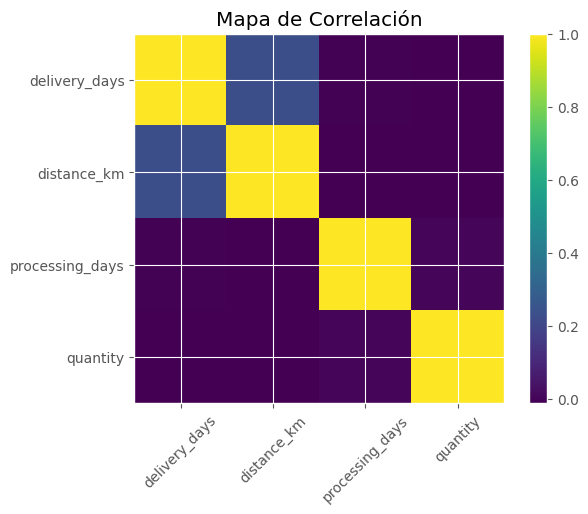

In [5]:
# 5️⃣ Heatmap de correlación
corr = df[["delivery_days", "distance_km", "processing_days", "quantity"]].corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Mapa de Correlación")
plt.show()

### 6. Boxplot por región
Este gráfico compara los tiempos de entrega según la región del cliente. Permite identificar qué zonas reciben los pedidos más rápido o más lento.

<Figure size 640x480 with 0 Axes>

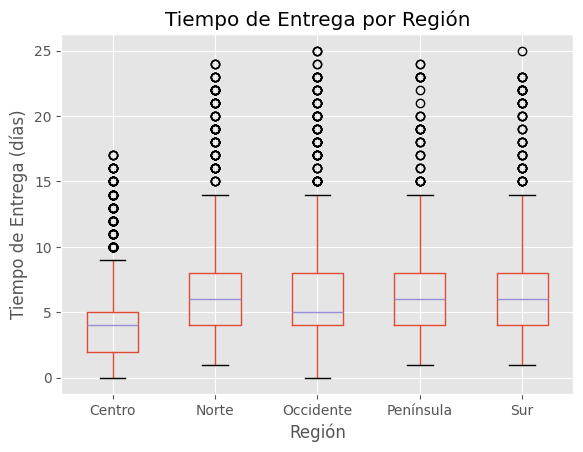

In [6]:
# 6️⃣ Boxplot por región
plt.figure()
df.boxplot(column="delivery_days", by="customer_region")
plt.title("Tiempo de Entrega por Región")
plt.suptitle("")
plt.xlabel("Región")
plt.ylabel("Tiempo de Entrega (días)")
plt.show()

### 7. Entregas rápidas vs lentas
El gráfico circular nos muestra la proporción de entregas rápidas (≤3 días) y lentas (>3 días). Así podemos tener una visión rápida de la eficiencia general de nuestras entregas.

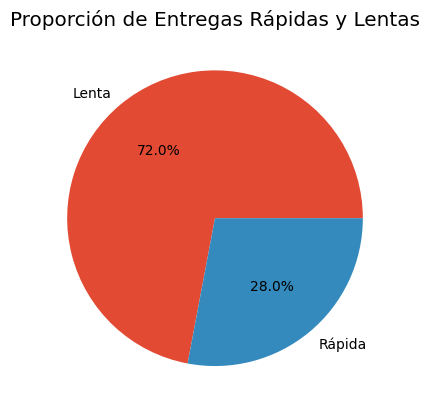

In [8]:
# 7️⃣ Entregas rápidas vs lentas
df["categoria_tiempo"] = df["delivery_days"].apply(
    lambda x: "Rápida" if x <= 3 else "Lenta"
)

conteo = df["categoria_tiempo"].value_counts()

plt.figure()
plt.pie(conteo, labels=conteo.index, autopct="%1.1f%%")
plt.title("Proporción de Entregas Rápidas y Lentas")
plt.show()

### 8. Preparación vs tiempo
Este scatter compara los días de preparación del pedido con el tiempo total de entrega. Nos ayuda a ver si preparar más rápido se traduce en entregas más rápidas.

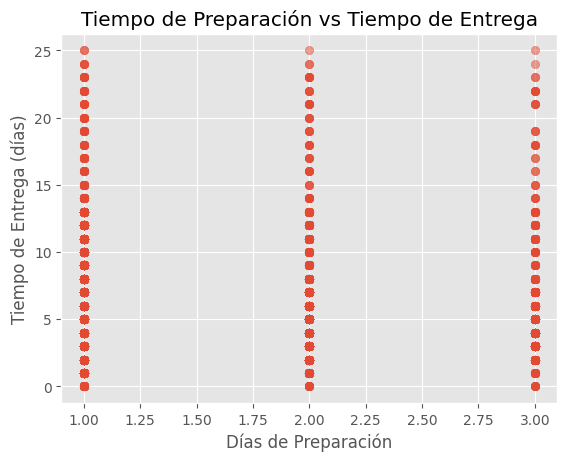

In [9]:
# 8️⃣ Preparación vs tiempo
plt.figure()
plt.scatter(df["processing_days"], df["delivery_days"], alpha=0.5)
plt.title("Tiempo de Preparación vs Tiempo de Entrega")
plt.xlabel("Días de Preparación")
plt.ylabel("Tiempo de Entrega (días)")
plt.show()


### 9. Tiempo promedio por método de pago
Aquí comparamos el tiempo promedio de entrega según el método de pago utilizado. Nos permite identificar si algún método influye en la velocidad de entrega.

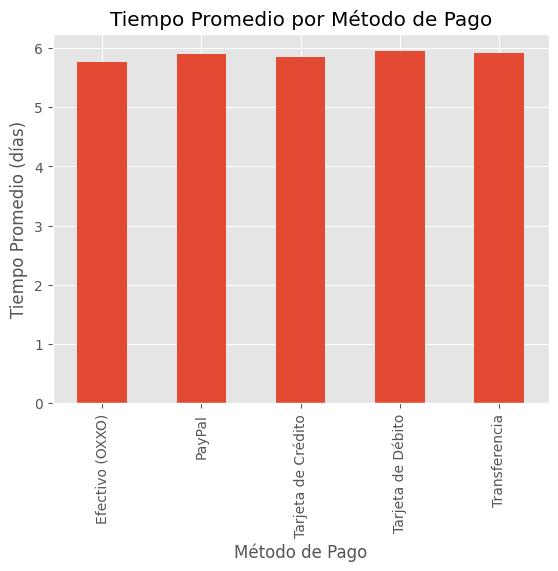

In [10]:
# 9️⃣ Tiempo promedio por método de pago          
promedio_pago = df.groupby("payment_method")["delivery_days"].mean()

plt.figure()
promedio_pago.plot(kind="bar")
plt.title("Tiempo Promedio por Método de Pago")
plt.xlabel("Método de Pago")
plt.ylabel("Tiempo Promedio (días)")
plt.show()

### 10. Boxplot por cantidad de productos
Este gráfico muestra cómo afecta la cantidad de productos en un pedido al tiempo de entrega. Podemos ver si los pedidos grandes tardan más que los pequeños.

<Figure size 640x480 with 0 Axes>

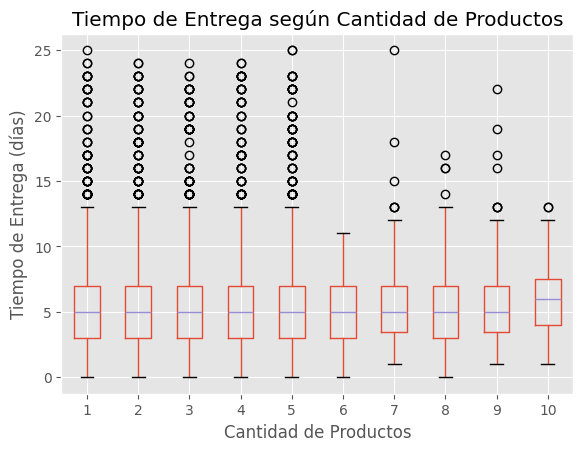

In [11]:

# 🔟 Boxplot por cantidad de productos
plt.figure()
df.boxplot(column="delivery_days", by="quantity")
plt.title("Tiempo de Entrega según Cantidad de Productos")
plt.suptitle("")
plt.xlabel("Cantidad de Productos")
plt.ylabel("Tiempo de Entrega (días)")
plt.show()


# Conclusiones del Análisis de Tiempos de Entrega

## 1️⃣ Distribución general de entregas
La mayoría de los pedidos se entregan en un rango de **2 a 4 días**, lo que indica que el proceso logístico es relativamente rápido en general.

## 2️⃣ Impacto del tipo de envío
Los **envíos express o prioritarios** suelen ser más rápidos, mientras que los estándares tienen más variabilidad. Esto confirma que el tipo de envío afecta directamente la rapidez de entrega.

## 3️⃣ Distancia del envío
Existe una relación positiva entre la **distancia y el tiempo de entrega**: pedidos más lejanos tardan más en llegar.

## 4️⃣ Comparación entre paqueterías
Algunas **paqueterías son más eficientes** que otras, lo que permite identificar a los proveedores más confiables para reducir tiempos de entrega promedio.

## 5️⃣ Relaciones entre variables
La correlación entre **días de preparación y días de entrega** muestra que pedidos que tardan más en prepararse tienden a tardar más en llegar, aunque la relación no es completamente lineal.

## 6️⃣ Impacto de la región del cliente
Algunas **regiones reciben los pedidos más rápido** que otras, lo que puede reflejar diferencias en la logística regional o disponibilidad de transporte.

## 7️⃣ Proporción de entregas rápidas y lentas
Una buena parte de los pedidos se entrega rápidamente (≤3 días), pero aún existe un porcentaje de **entregas lentas** que podrían optimizarse.

## 8️⃣ Preparación del pedido
Los pedidos con **menos días de preparación** tienden a ser entregados más rápido, confirmando que la eficiencia en el proceso interno impacta directamente en la entrega.

## 9️⃣ Método de pago
Algunos **métodos de pago** pueden influir en el tiempo de entrega, probablemente por procesos adicionales de validación o autorización.

## 🔟 Cantidad de productos en el pedido
Pedidos con **más productos** tienden a tardar un poco más, lo que sugiere que la complejidad del pedido influye en la rapidez de la entrega.
